<a href="https://colab.research.google.com/github/rajat805/rajat805/blob/main/Another_copy_of_Sample_ML_Submission_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -  INDIA AIR QUALITY



##### **Project Type**    - EDA/Regression


# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

https://github.com/rajat805

# **Problem Statement**


Air pollution has become one of the most significant environmental challenges, directly affecting public health and quality of life. The Air Quality Index (AQI) is a widely used indicator that measures air pollution levels based on pollutant concentrations and environmental conditions. Accurate prediction of AQI enables governments, environmental agencies, and citizens to take preventive actions against poor air quality.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Librarie
# Data Manipulation
import pandas as pd
import numpy as np
import missingno as msno
# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Styling
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Increase default figure size
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

### Dataset Loading

In [ ]:
# Load Dataset
df = pd.read_csv("/content/enriched_aqi_dataset.csv")
display(df.head())

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg,AQI,AQI_Bucket,Temperature_C,Humidity_%,Wind_Speed_kmh,Year,Month,Day,Hour,Day_of_Week,Season
0,India,Andhra Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",2026-07-01 23:00:00.000000000,14.465052,78.824187,OZONE,39.0,41.0,40.0,20,Good,23.8,68.2,10.6,2026,7,1,23,2,Summer
1,India,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",2026-07-01 23:00:00.000000000,16.186555,81.132190,NO2,13.0,33.0,18.0,15,Good,30.6,60.3,19.1,2026,7,1,23,2,Summer
2,India,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",2026-07-01 23:00:00.000000000,16.186555,81.132190,NH3,3.0,5.0,4.0,1,Good,28.4,44.3,8.8,2026,7,1,23,2,Summer
3,India,Andhra Pradesh,Nellore,"Ambedkar Nagar, Nellore - APPCB",2026-07-01 23:00:00.000000000,14.438164,79.966814,PM10,45.0,106.0,66.0,96,Moderate,39.6,38.9,2.5,2026,7,1,23,2,Summer
4,India,Andhra Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",2026-07-01 23:00:00.000000000,16.987287,81.736318,PM2.5,5.0,19.0,11.0,12,Good,21.4,47.7,28.3,2026,7,1,23,2,Summer


### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg,AQI,AQI_Bucket,Temperature_C,Humidity_%,Wind_Speed_kmh,Year,Month,Day,Hour,Day_of_Week,Season
0,India,Andhra Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",2026-07-01 23:00:00.000000000,14.465052,78.824187,OZONE,39.0,41.0,40.0,20,Good,23.8,68.2,10.6,2026,7,1,23,2,Summer
1,India,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",2026-07-01 23:00:00.000000000,16.186555,81.132190,NO2,13.0,33.0,18.0,15,Good,30.6,60.3,19.1,2026,7,1,23,2,Summer
2,India,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",2026-07-01 23:00:00.000000000,16.186555,81.132190,NH3,3.0,5.0,4.0,1,Good,28.4,44.3,8.8,2026,7,1,23,2,Summer
3,India,Andhra Pradesh,Nellore,"Ambedkar Nagar, Nellore - APPCB",2026-07-01 23:00:00.000000000,14.438164,79.966814,PM10,45.0,106.0,66.0,96,Moderate,39.6,38.9,2.5,2026,7,1,23,2,Summer
4,India,Andhra Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",2026-07-01 23:00:00.000000000,16.987287,81.736318,PM2.5,5.0,19.0,11.0,12,Good,21.4,47.7,28.3,2026,7,1,23,2,Summer


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count

print(df.shape)

# To get them individually:
rows = df.shape[0]
cols = df.shape[1]



(10521, 22)


### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10521 entries, 0 to 10520
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         10521 non-null  object 
 1   state           10521 non-null  object 
 2   city            10521 non-null  object 
 3   station         10521 non-null  object 
 4   last_update     10521 non-null  object 
 5   latitude        10521 non-null  float64
 6   longitude       10521 non-null  float64
 7   pollutant_id    10521 non-null  object 
 8   pollutant_min   10164 non-null  float64
 9   pollutant_max   10164 non-null  float64
 10  pollutant_avg   10164 non-null  float64
 11  AQI             10521 non-null  int64  
 12  AQI_Bucket      10521 non-null  object 
 13  Temperature_C   10521 non-null  float64
 14  Humidity_%      10521 non-null  float64
 15  Wind_Speed_kmh  10521 non-null  float64
 16  Year            10521 non-null  int64  
 17  Month           10521 non-null 

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
country,0
state,0
city,0
station,0
last_update,0
latitude,0
longitude,0
pollutant_id,0
pollutant_min,357
pollutant_max,357


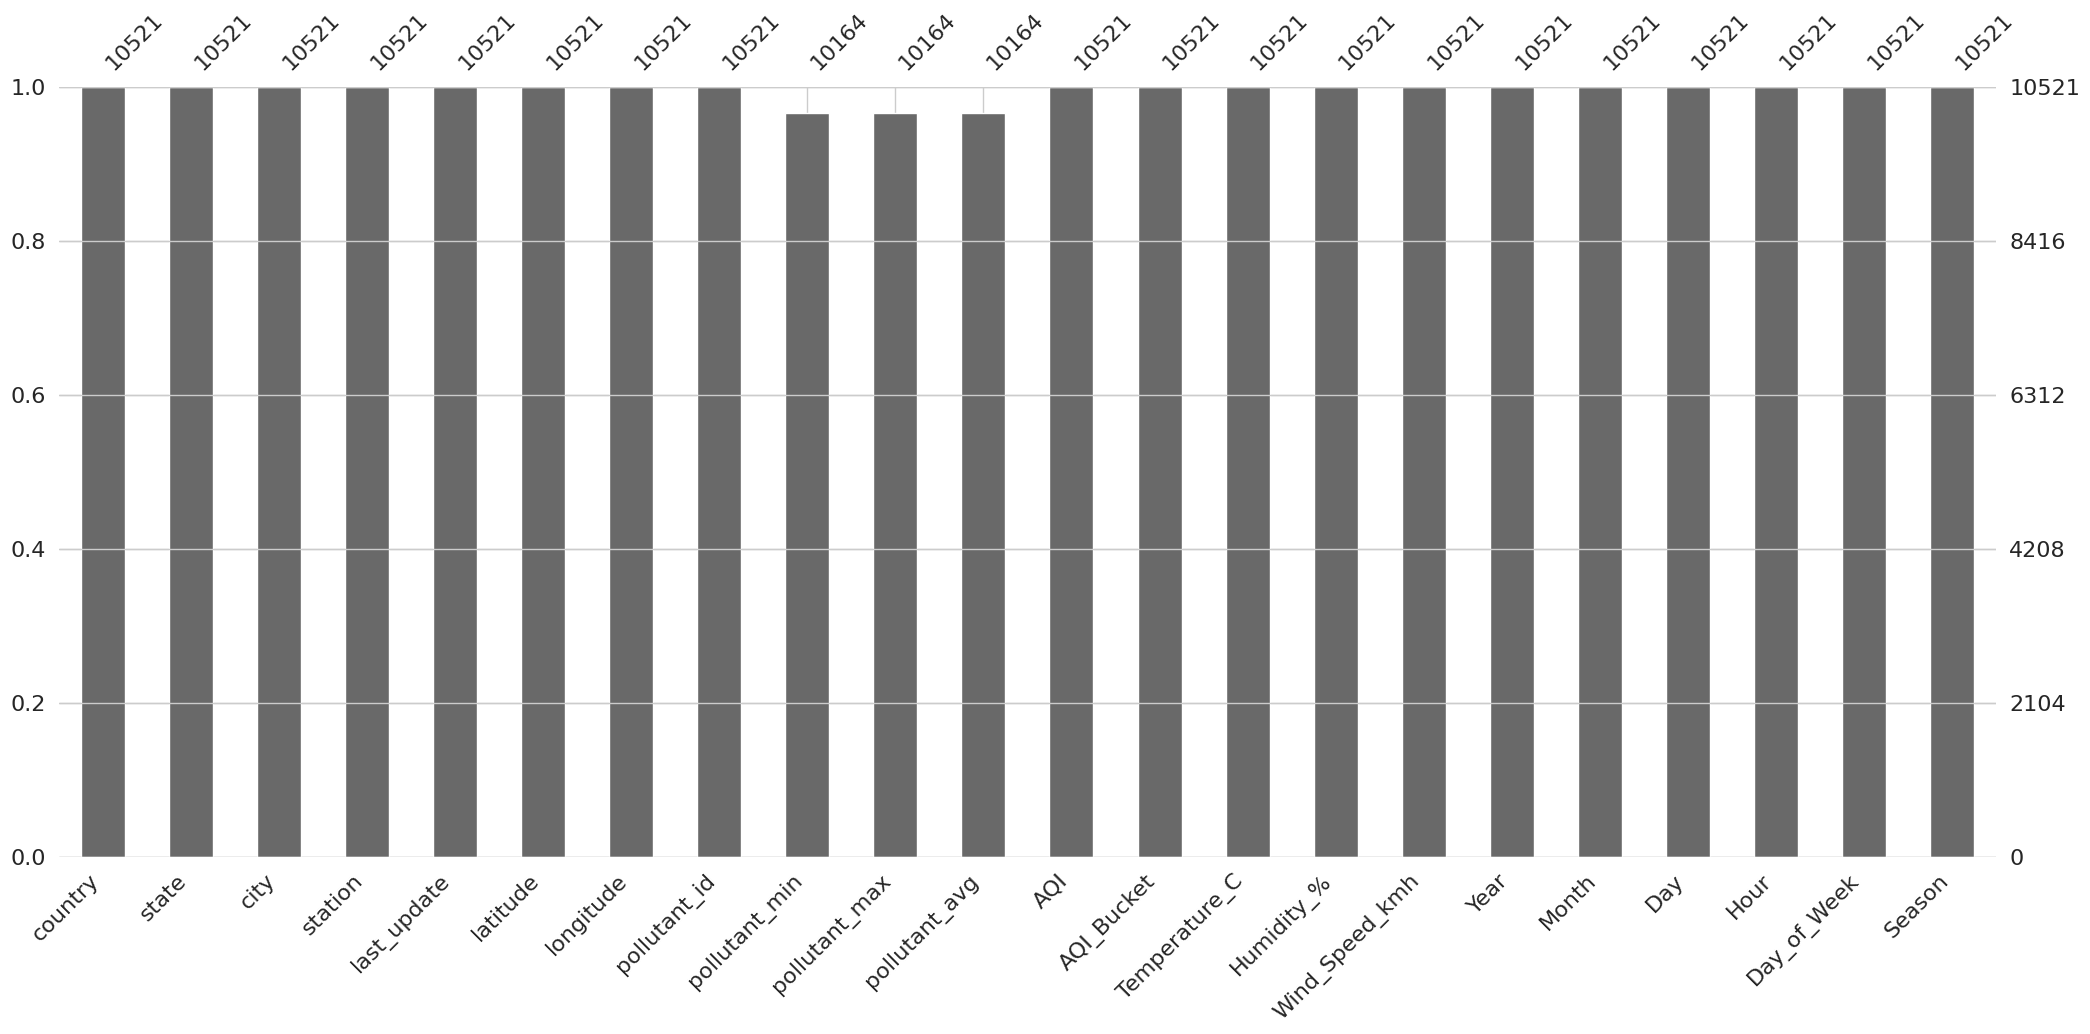

In [ ]:
# Visualizing the missing values
msno.bar(df)
plt.show()

### What did you know about your dataset?

Answer Here

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns

Index(['country', 'state', 'city', 'station', 'last_update', 'latitude',
       'longitude', 'pollutant_id', 'pollutant_min', 'pollutant_max',
       'pollutant_avg', 'AQI', 'AQI_Bucket', 'Temperature_C', 'Humidity_%',
       'Wind_Speed_kmh', 'Year', 'Month', 'Day', 'Hour', 'Day_of_Week',
       'Season'],
      dtype='object')

In [ ]:
# Dataset Describe
df.describe()

,latitude,longitude,pollutant_min,pollutant_max,pollutant_avg,AQI,Temperature_C,Humidity_%,Wind_Speed_kmh,Year,Month,Day,Hour,Day_of_Week
count,10521.000000,10521.000000,10164.000000,10164.000000,10164.000000,10521.000000,10521.000000,10521.000000,10521.000000,10521.000000,10521.000000,10521.000000,10521.000000,10521.000000
mean,21.970147,81.228132,50.536787,233.356966,100.840329,118.237430,27.584621,62.351250,15.071875,2025.986693,6.670374,10.797453,15.327535,2.668092
std,6.798401,6.560283,53.954573,161.227762,81.948059,103.562225,7.231523,18.940531,8.673204,0.669696,2.813108,9.957950,7.882064,1.684897
min,8.514909,70.776774,0.000000,0.000000,0.000000,0.000000,15.000000,30.000000,0.000000,2025.000000,1.000000,1.000000,0.000000,0.000000
25%,16.690571,75.905894,10.000000,62.000000,26.000000,33.000000,21.300000,45.900000,7.600000,2026.000000,5.000000,1.000000,8.000000,2.000000
50%,22.568732,79.946728,29.250000,247.850000,80.600000,89.000000,27.600000,62.200000,15.100000,2026.000000,7.000000,8.000000,18.000000,2.000000
75%,27.759769,86.590325,74.200000,377.225000,170.400000,183.000000,33.900000,79.000000,22.700000,2026.000000,8.000000,19.000000,23.000000,4.000000
max,34.066206,94.636574,262.000000,500.000000,266.000000,499.000000,40.000000,95.000000,30.000000,2027.000000,12.000000,31.000000,23.000000,6.000000


### Variables Description

Answer Here

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for Each Variable

for column in df.columns:
    print(f"\n{'='*60}")
    print(f"Column: {column}")
    print(f"Number of Unique Values: {df[column].nunique()}")
    print(df[column].unique())


Column: country
Number of Unique Values: 1
['India']

Column: state
Number of Unique Values: 30
['Andhra Pradesh' 'Arunachal Pradesh' 'Assam' 'Chhattisgarh' 'Delhi'
 'Bihar' 'Chandigarh' 'Gujarat' 'Haryana' 'Karnataka' 'Himachal Pradesh'
 'Jammu and Kashmir' 'Jharkhand' 'Kerala' 'Madhya Pradesh' 'Maharashtra'
 'Odisha' 'Puducherry' 'Punjab' 'Rajasthan' 'Meghalaya' 'Mizoram'
 'Nagaland' 'Telangana' 'Uttar Pradesh' 'Tamil Nadu' 'Sikkim' 'Tripura'
 'Uttarakhand' 'West Bengal']

Column: city
Number of Unique Values: 268
['Kadapa' 'Machilipatnam' 'Nellore' 'Rajamahendravaram' 'Tirumala'
 'Tirupati' 'Vijayawada' 'Visakhapatnam' 'Naharlagun' 'Byrnihat'
 'Guwahati' 'Nagaon' 'Silchar' 'Tumidih' 'Delhi' 'Sivasagar' 'Araria'
 'Arrah' 'Aurangabad' 'Begusarai' 'Bhagalpur' 'Muzaffarpur' 'Patna'
 'Rajgir' 'Samastipur' 'Siwan' 'Chandigarh' 'Bhilai' 'Katihar'
 'Kishanganj' 'Manguraha' 'Motihari' 'Munger' 'Bihar Sharif' 'Buxar'
 'Chhapra' 'Gaya' 'Amaravati' 'Anantapur' 'Eluru' 'Bilaspur' 'Kunjemura'
 '

## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# ==========================================
# DATA WRANGLING
# ==========================================

import pandas as pd
import numpy as np

print("="*60)
print("DATA WRANGLING")
print("="*60)

# 1. Dataset Shape
print("\n1. Dataset Shape")
print(df.shape)

# 2. Dataset Information
print("\n2. Dataset Information")
df.info()

# 3. Duplicate Records
print("\n3. Duplicate Records")
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

# Remove duplicates
df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

# 4. Missing Values
print("\n4. Missing Values")

missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': round((df.isnull().sum()/len(df))*100,2)
})

print(missing)

# 5. Fill Missing Values

num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include='object').columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After Treatment")
print(df.isnull().sum())

# 6. Data Types
print("\n6. Data Types")
print(df.dtypes)

# 7. Unique Values
print("\n7. Unique Values")

for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

# 8. Statistical Summary
print("\n8. Numerical Summary")
print(df.describe().T)

print("\n9. Categorical Summary")
print(df.describe(include='object').T)

# 10. Outlier Detection (Only Detect)
print("\n10. Outlier Detection (IQR Method)")

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

outlier_summary = []

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append([col, outliers])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Feature", "Number of Outliers"]
)

print(outlier_df)

# 11. Outlier Treatment
print("\n11. Outlier Treatment")

print("Outliers were detected but NOT removed.")
print("Reason: Extreme AQI values may represent genuine pollution events.")
print("Removing them could reduce the model's ability to predict high pollution levels.")

# 12. Final Dataset Shape
print("\n12. Final Dataset Shape")
print(df.shape)

print("\n")
print("="*60)
print("DATA WRANGLING COMPLETED SUCCESSFULLY")
print("="*60)

DATA WRANGLING

1. Dataset Shape
(10521, 22)

2. Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10521 entries, 0 to 10520
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         10521 non-null  object 
 1   state           10521 non-null  object 
 2   city            10521 non-null  object 
 3   station         10521 non-null  object 
 4   last_update     10521 non-null  object 
 5   latitude        10521 non-null  float64
 6   longitude       10521 non-null  float64
 7   pollutant_id    10521 non-null  object 
 8   pollutant_min   10164 non-null  float64
 9   pollutant_max   10164 non-null  float64
 10  pollutant_avg   10164 non-null  float64
 11  AQI             10521 non-null  int64  
 12  AQI_Bucket      10521 non-null  object 
 13  Temperature_C   10521 non-null  float64
 14  Humidity_%      10521 non-null  float64
 15  Wind_Speed_kmh  10521 non-null  float64
 16  Year   

### What all manipulations have you done and insights you found?

Answer Here.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 -Distribution of AQI Levels

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set global styling for a clean, professional look
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 14, 'axes.labelsize': 12})

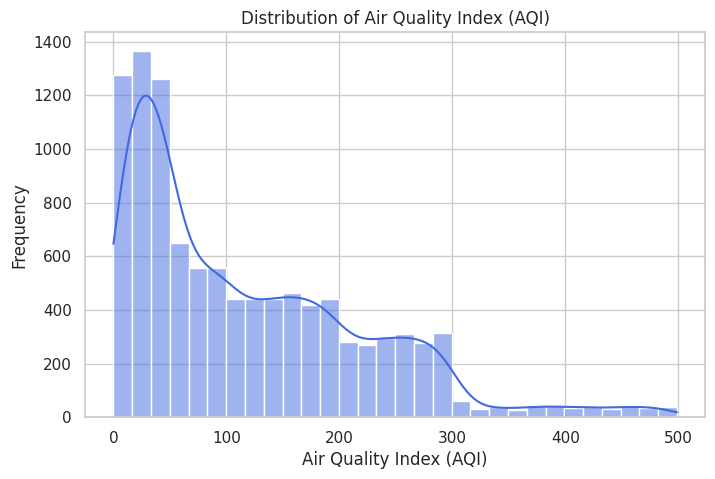

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['AQI'], bins=30, kde=True, color='royalblue')

plt.title('Distribution of Air Quality Index (AQI)')
plt.xlabel('Air Quality Index (AQI)')
plt.ylabel('Frequency')

plt.show()



##### 1. Why did you pick the specific chart?

Histogram is ideal for understanding the distribution of a continuous numerical variable like AQI.

##### 2. What is/are the insight(s) found from the chart?

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2-. Top 10 Most Polluted States

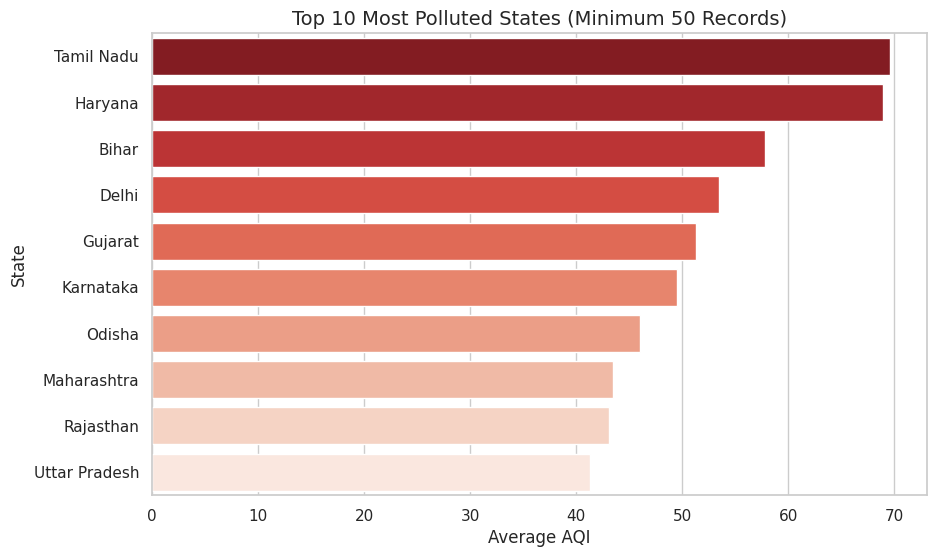

In [ ]:
state_stats = (
    df.groupby('state')
      .agg(
          Average_AQI=('AQI', 'mean'),
          Records=('AQI', 'count')
      )
)

state_stats = state_stats[state_stats['Records'] >= 50]

top_states = state_stats.sort_values(
    'Average_AQI',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_states['Average_AQI'],
    y=top_states.index,
    palette='Reds_r'
)

plt.title("Top 10 Most Polluted States (Minimum 50 Records)")
plt.xlabel("Average AQI")
plt.ylabel("State")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

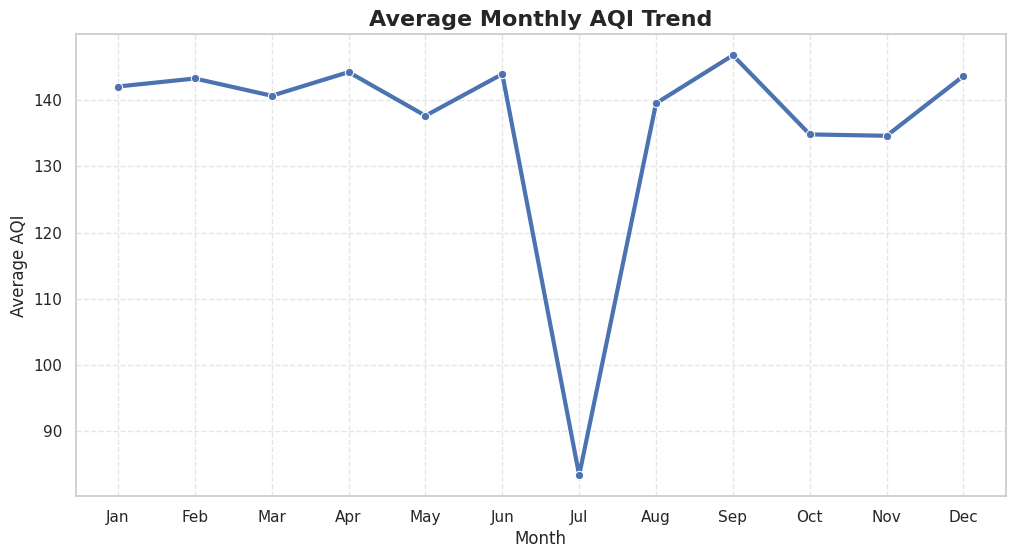

In [ ]:
monthly = (
    df.groupby('Month', as_index=False)['AQI']
      .mean()
      .sort_values('Month')
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly,
    x='Month',
    y='AQI',
    marker='o',
    linewidth=3
)

plt.xticks(range(1,13),
           ['Jan','Feb','Mar','Apr','May','Jun',
            'Jul','Aug','Sep','Oct','Nov','Dec'])

plt.title("Average Monthly AQI Trend", fontsize=16, weight='bold')
plt.xlabel("Month")
plt.ylabel("Average AQI")

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [ ]:
print(df['Month'].value_counts())

Month
7    3289
Name: count, dtype: int64


##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

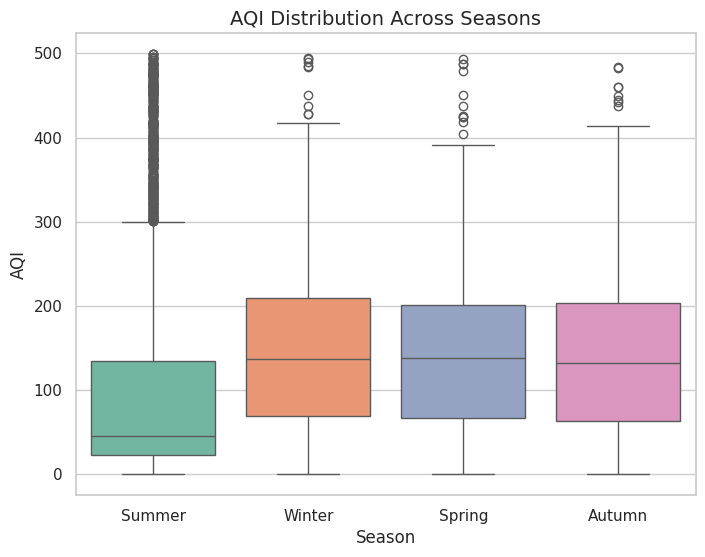

In [ ]:
# Chart - 4 visualization code
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='Season',
    y='AQI',
    palette='Set2'
)

plt.title("AQI Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("AQI")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5-Average AQI by Pollutant Type

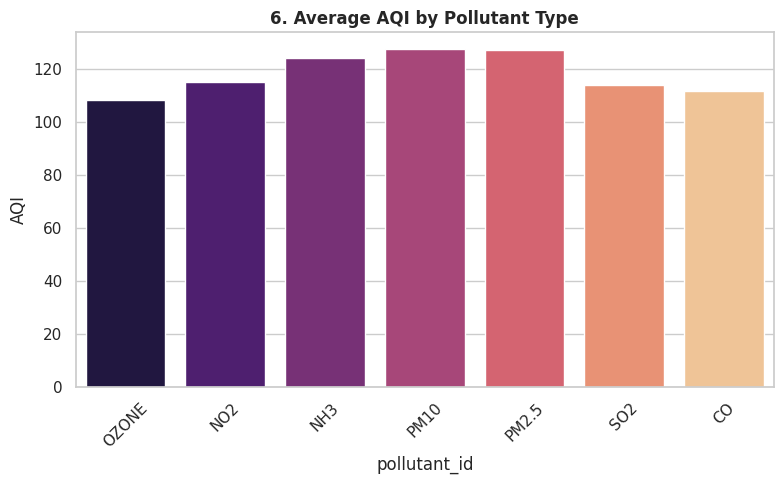

In [ ]:
plt.figure(figsize=(8, 5))
if 'pollutant_id' in df.columns:
    sns.barplot(data=df, x='pollutant_id', y='AQI', hue='pollutant_id', palette='magma', errorbar=None, legend=False)
    plt.title("6. Average AQI by Pollutant Type", weight='bold')
    plt.xticks(rotation=45)
else:
    plt.text(0.5, 0.5, "'pollutant_id' column missing", ha='center', va='center', fontsize=12)
    plt.title("6. AQI by Pollutant Type (Unavailable)", weight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [ ]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [ ]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [ ]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [ ]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [ ]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [ ]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [ ]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [ ]:
# Pair Plot visualization code
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [40]:
# Check for missing values
print(df.isnull().sum())

# Dropping rows with missing target values (AQI) if any exist
df = df.dropna(subset=['AQI'])

# For other numerical columns, we can fill missing values with the median
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

country           0
state             0
city              0
station           0
last_update       0
latitude          0
longitude         0
pollutant_id      0
pollutant_min     0
pollutant_max     0
pollutant_avg     0
AQI               0
AQI_Bucket        0
Temperature_C     0
Humidity_%        0
Wind_Speed_kmh    0
Year              0
Month             0
Day               0
Hour              0
Day_of_Week       0
Season            0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

##### What all outlier treatment techniques have you used and why did you use those techniques?

In [41]:
# Dropping columns that aren't useful for a baseline linear regression
columns_to_drop = ['country', 'station', 'last_update', 'latitude', 'longitude', 'AQI_Bucket']
df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')

Answer Here.

### 3. Categorical Encoding

In [42]:
# Encode your categorical columns
# One-hot encode categorical features
categorical_cols = ['state', 'city', 'pollutant_id', 'Season']
df_encoded = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [43]:
# Split your data to train and test. Choose Splitting ratio wisely.

from sklearn.model_selection import train_test_split

# Define features and target
X = df_encoded.drop(columns=['AQI'])
y = df_encoded['AQI']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


##### What data splitting ratio have you used and why?

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [44]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Preprocessing Complete!")
print(f"Training shape: {X_train_scaled.shape}, Testing shape: {X_test_scaled.shape}")

Data Preprocessing Complete!
Training shape: (8416, 316), Testing shape: (2105, 316)


In [45]:
### very impoertant
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model on the preprocessed training data
model.fit(X_train_scaled, y_train)

LinearRegression()

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict on the test data
y_pred = model.predict(X_test_scaled)

# Calculate performance metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display results
print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): 35.11
Root Mean Squared Error (RMSE): 56.53
R-squared (R2) Score: 0.6582


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [38]:
# ==========================================
# ML Model 1 - Linear Regression with GridSearchCV
# ==========================================

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

# Create Model
lr = LinearRegression()

# Hyperparameter Grid
param_grid = {
    'fit_intercept': [True, False]
}

# Grid Search with 5-Fold Cross Validation
grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Train Model
grid_lr.fit(X_train_scaled, y_train)

# Best Parameters
print("Best Parameters:", grid_lr.best_params_)

# Best Cross Validation Score
print("Best CV Score:", round(grid_lr.best_score_, 4))

# Best Model
best_lr = grid_lr.best_estimator_

# Prediction
y_pred_lr = best_lr.predict(X_test_scaled)

Best Parameters: {'fit_intercept': True}
Best CV Score: 0.599


In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("-"*35)
print(f"MAE  : {mae_lr:.2f}")
print(f"MSE  : {mse_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R²   : {r2_lr:.4f}")

Linear Regression Performance
-----------------------------------
MAE  : 35.11
MSE  : 3195.43
RMSE : 56.53
R²   : 0.6582


##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [48]:
from sklearn.linear_model import Lasso
# Create Lasso Model
lasso_model = Lasso(alpha=1.0, random_state=42)

# Train the Model
lasso_model.fit(X_train_scaled, y_train)

# Prediction
y_pred_lasso = lasso_model.predict(X_test_scaled)

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression Performance")
print("-"*35)
print(f"MAE      : {mae_lasso:.2f}")
print(f"MSE      : {mse_lasso:.2f}")
print(f"RMSE     : {rmse_lasso:.2f}")
print(f"R² Score : {r2_lasso:.4f}")

Lasso Regression Performance
-----------------------------------
MAE      : 32.63
MSE      : 3092.89
RMSE     : 55.61
R² Score : 0.6691


In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [50]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter Grid
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

# Grid Search
grid_lasso = GridSearchCV(
    estimator=Lasso(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Train
grid_lasso.fit(X_train_scaled, y_train)

# Best Parameters
print("Best Parameters:", grid_lasso.best_params_)

# Best CV Score
print("Best Cross Validation Score:", round(grid_lasso.best_score_,4))

Best Parameters: {'alpha': 1}
Best Cross Validation Score: 0.6044


In [51]:
best_lasso = grid_lasso.best_estimator_

y_pred_lasso_cv = best_lasso.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_lasso_cv)
mse = mean_squared_error(y_test, y_pred_lasso_cv)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lasso_cv)

print("Lasso Regression after GridSearchCV")
print("-"*40)
print(f"MAE      : {mae:.2f}")
print(f"MSE      : {mse:.2f}")
print(f"RMSE     : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

Lasso Regression after GridSearchCV
----------------------------------------
MAE      : 32.63
MSE      : 3092.89
RMSE     : 55.61
R² Score : 0.6691


##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [52]:
from sklearn.linear_model import Ridge
# Create Ridge Model
ridge_model = Ridge(alpha=1.0, random_state=42)

# Train the Model
ridge_model.fit(X_train_scaled, y_train)

# Prediction
y_pred_ridge = ridge_model.predict(X_test_scaled)

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Performance")
print("-"*35)
print(f"MAE      : {mae_ridge:.2f}")
print(f"MSE      : {mse_ridge:.2f}")
print(f"RMSE     : {rmse_ridge:.2f}")
print(f"R² Score : {r2_ridge:.4f}")

Ridge Regression Performance
-----------------------------------
MAE      : 35.11
MSE      : 3195.29
RMSE     : 56.53
R² Score : 0.6582


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [54]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter Grid
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

# Grid Search
grid_ridge = GridSearchCV(
    estimator=Ridge(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Train
grid_ridge.fit(X_train_scaled, y_train)

# Best Parameters
print("Best Parameters:", grid_ridge.best_params_)

# Best Cross Validation Score
print("Best Cross Validation Score:", round(grid_ridge.best_score_, 4))

Best Parameters: {'alpha': 100}
Best Cross Validation Score: 0.5991


In [55]:
best_ridge = grid_ridge.best_estimator_

y_pred_ridge_cv = best_ridge.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_ridge_cv)
mse = mean_squared_error(y_test, y_pred_ridge_cv)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_ridge_cv)

print("Ridge Regression after GridSearchCV")
print("-"*40)
print(f"MAE      : {mae:.2f}")
print(f"MSE      : {mse:.2f}")
print(f"RMSE     : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

Ridge Regression after GridSearchCV
----------------------------------------
MAE      : 34.92
MSE      : 3185.81
RMSE     : 56.44
R² Score : 0.6592


##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***